In [102]:
from mpl_toolkits import mplot3d

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow as gpf
from gpflow.utilities import print_summary
import matplotlib.dates as mdates

# The lines below are specific to the notebook format
%matplotlib inline
#%matplotlib notebook
#%matplotlib qt
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams.update({'font.size': 24})

dtyp = np.float64
gpf.config.set_default_float(dtyp)

print("Tensorflow version " + tf.__version__)
print(f"Tensorflow Probability: {tfp.__version__}")
print(f"GPFlow {gpf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "NOT AVAILABLE")

try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])

  tf.config.experimental_connect_to_cluster(tpu)
  tf.tpu.experimental.initialize_tpu_system(tpu)
  tpu_strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
  msg = 'WARNING: Not connected to a TPU runtime; please see the previous cell in this notebook for instructions!'
  print(msg)

tf.config.experimental.set_visible_devices([], 'GPU') # Turn off GPU (for M1 Mac, hopefully temporary!)
#tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(False)

print('Physical: ', tf.config.list_physical_devices())
print('Logical: ', tf.config.list_logical_devices())

Tensorflow version 2.8.0
Tensorflow Probability: 0.16.0
GPFlow 2.4.0
GPU is available
Physical:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical:  [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


## Load training data

,actual_species_ratio_compared_to_observed,habitat_scale,irs_rescale_factor,population_rescale_factor,regional_eir_scale,Run_Number,sample,year,month,cases
0,0.550957,8.0,1.045341,0.995135,1.620418,1,0,2014.0,1.0,184.099896
1,0.550957,8.0,1.045341,0.995135,1.620418,1,0,2014.0,2.0,162.953286
2,0.550957,8.0,1.045341,0.995135,1.620418,1,0,2014.0,3.0,405.268555
3,0.550957,8.0,1.045341,0.995135,1.620418,1,0,2014.0,4.0,474.679191
4,0.550957,8.0,1.045341,0.995135,1.620418,1,0,2014.0,5.0,402.531935
...,...,...,...,...,...,...,...,...,...,...
15355,0.317184,8.0,1.036623,1.000000,1.589803,4,63,2018.0,8.0,5.500000
15356,0.317184,8.0,1.036623,1.000000,1.589803,4,63,2018.0,9.0,7.000000
15357,0.317184,8.0,1.036623,1.000000,1.589803,4,63,2018.0,10.0,11.500000
15358,0.317184,8.0,1.036623,1.000000,1.589803,4,63,2018.0,11.0,21.250000


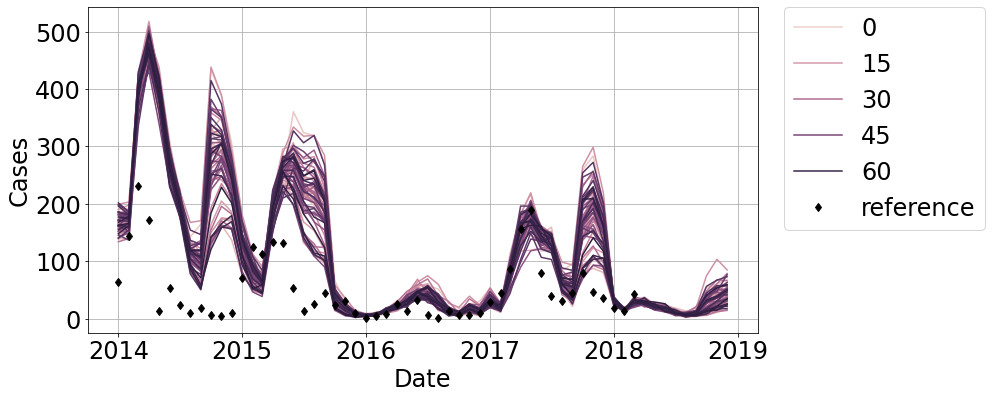

In [106]:
dfx = pd.read_csv('sim_output_with_tags.csv')
display(dfx)
pars = ['actual_species_ratio_compared_to_observed', 'habitat_scale', 'irs_rescale_factor', 'population_rescale_factor', 'regional_eir_scale']

# Run_Number is not working, so just keep 1
dfx = dfx.loc[ dfx['Run_Number']==1]
dfx['day'] = 1
dfx['fulldate'] = pd.to_datetime( dfx[['year', 'month', 'day']])
#dfx.rename(columns={'cases': 'cases_sim'})

fig, ax = plt.subplots()
sns.lineplot(data=dfx, x='fulldate', y='cases', hue='sample', ax=ax)

dfy = pd.read_csv('reference.csv')
dfy['fulldate'] = pd.to_datetime(dfy['fulldate'])
ax.plot(dfy['fulldate'], dfy['cases'], 'kd', label='reference')
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

ax.legend(bbox_to_anchor=(1.04,1), borderaxespad=0)
ax.set_xlabel('Date')
ax.set_ylabel('Cases')
ax.grid()

In [104]:
import datetime as dt
first = dt.datetime(2016,1,1)
df = dfx.loc[dfx['fulldate']>=first].groupby('sample')['cases'].sum()
ref = dfy.loc[dfx['fulldate']>=first]['cases'].sum()
display(df)
display(ref)

sample
0     1936.034311
1     2078.500000
2     1871.705487
3     2470.000000
4     1746.433407
         ...     
59    1556.761792
60    2011.984662
61    1549.250000
62    2054.750000
63    1712.500000
Name: cases, Length: 64, dtype: float64

1064

In [105]:
X = dfx.groupby('sample').first()[pars].values.reshape(-1, len(pars)).astype(dtyp)
Y = dfx.loc[dfx['fulldate']>=first].groupby('sample')['cases'].sum().values.reshape(-1, 1).astype(dtyp)
display(X)

# Normalize model outputs
muY = Y.mean()
Y = Y-muY
rangeY = Y.max() - Y.min()
Y = 2 * Y / rangeY

# Normalize the reference
refn = 2*(ref-muY)/rangeY

# Box the model inputs
#display(2*(X - X.mean(axis=0)) / (X.max(axis=0)-X.min(axis=0)))

array([[0.55095669, 8.        , 1.04534125, 0.99513457, 1.62041843],
       [0.59840504, 7.97076123, 0.97252253, 1.        , 2.        ],
       [0.47185634, 8.        , 1.03022141, 0.9445902 , 1.62085186],
       [1.68521188, 7.87817991, 0.95781932, 1.        , 1.79780003],
       [0.51913696, 8.        , 1.0066116 , 0.89721727, 1.69516243],
       [0.59783876, 8.        , 1.05547912, 1.        , 1.4036344 ],
       [0.54615311, 8.        , 1.05002631, 1.        , 1.61316092],
       [0.49904794, 8.        , 0.99244899, 1.        , 1.62550042],
       [0.25      , 7.97962056, 1.11343328, 0.9846783 , 1.63829702],
       [0.50352661, 8.        , 1.03680572, 1.        , 1.63332344],
       [0.82312232, 7.91702896, 0.90888311, 0.94205219, 1.92428791],
       [0.7287972 , 8.        , 1.05142454, 1.        , 1.49993468],
       [0.25      , 8.        , 1.06112313, 0.95680686, 1.7342403 ],
       [0.70539811, 8.        , 1.11750012, 0.96983076, 1.48184887],
       [0.69448597, 7.9598795 , 1.

In [78]:
k = gpf.kernels.Matern52(lengthscales=[1]*X.shape[1])
print_summary(k)

╒═══════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                  │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞═══════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ Matern52.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │ 1.0            │
├───────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ Matern52.lengthscales │ Parameter │ Softplus    │         │ True        │ (5,)    │ float64 │ [1., 1., 1.... │
╘═══════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧════════════════╛


In [79]:
m = gpf.models.GPR(data=(X, Y), kernel=k, mean_function=None)
#m.likelihood.variance.assign(1)
#m.kernel.lengthscales.assign(0.3)
#m.kernel.variance.assign(1)
print_summary(m)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (5,)    │ float64 │ [1., 1., 1.... │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 1.0            │
╘═════════════════════════╧═══════════╧═

In [93]:
opt = gpf.optimizers.Scipy()

opt_logs = opt.minimize(m.training_loss, m.trainable_variables, options=dict(maxiter=10000))
print_summary(m)
display(opt_logs)
display(m.kernel.parameters)
display(X)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════════════════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                                  │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════════════════════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.109429975410084                      │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────────────────────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ (5,)    │ float64 │ [2.98846583, 0.78646241, 1.46640651... │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────────────────────────

      fun: -31.472683787911492
 hess_inv: <7x7 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 1.28499429e-07, -2.35249116e-06, -5.43035716e-07, -2.15760142e-06,
       -1.86460576e-07,  1.84490489e-06,  8.97713012e-06])
  message: 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
     nfev: 1
      nit: 0
     njev: 1
   status: 0
  success: True
        x: array([ 2.93678863,  0.1786611 ,  1.20406308, -0.5891757 ,  6.18593862,
        3.06377718, -4.41095583])

(<Parameter: name=softplus, dtype=float64, shape=[5], fn="softplus", numpy=array([2.98846583, 0.78646241, 1.46640651, 0.44133689, 6.18799467])>,
 <Parameter: name=softplus, dtype=float64, shape=[], fn="softplus", numpy=3.109429975410084>)

array([[0.55095669, 8.        , 1.04534125, 0.99513457, 1.62041843],
       [0.59840504, 7.97076123, 0.97252253, 1.        , 2.        ],
       [0.47185634, 8.        , 1.03022141, 0.9445902 , 1.62085186],
       [1.68521188, 7.87817991, 0.95781932, 1.        , 1.79780003],
       [0.51913696, 8.        , 1.0066116 , 0.89721727, 1.69516243],
       [0.59783876, 8.        , 1.05547912, 1.        , 1.4036344 ],
       [0.54615311, 8.        , 1.05002631, 1.        , 1.61316092],
       [0.49904794, 8.        , 0.99244899, 1.        , 1.62550042],
       [0.25      , 7.97962056, 1.11343328, 0.9846783 , 1.63829702],
       [0.50352661, 8.        , 1.03680572, 1.        , 1.63332344],
       [0.82312232, 7.91702896, 0.90888311, 0.94205219, 1.92428791],
       [0.7287972 , 8.        , 1.05142454, 1.        , 1.49993468],
       [0.25      , 8.        , 1.06112313, 0.95680686, 1.7342403 ],
       [0.70539811, 8.        , 1.11750012, 0.96983076, 1.48184887],
       [0.69448597, 7.9598795 , 1.

Percent of points within two standard deviations: 62.5%.


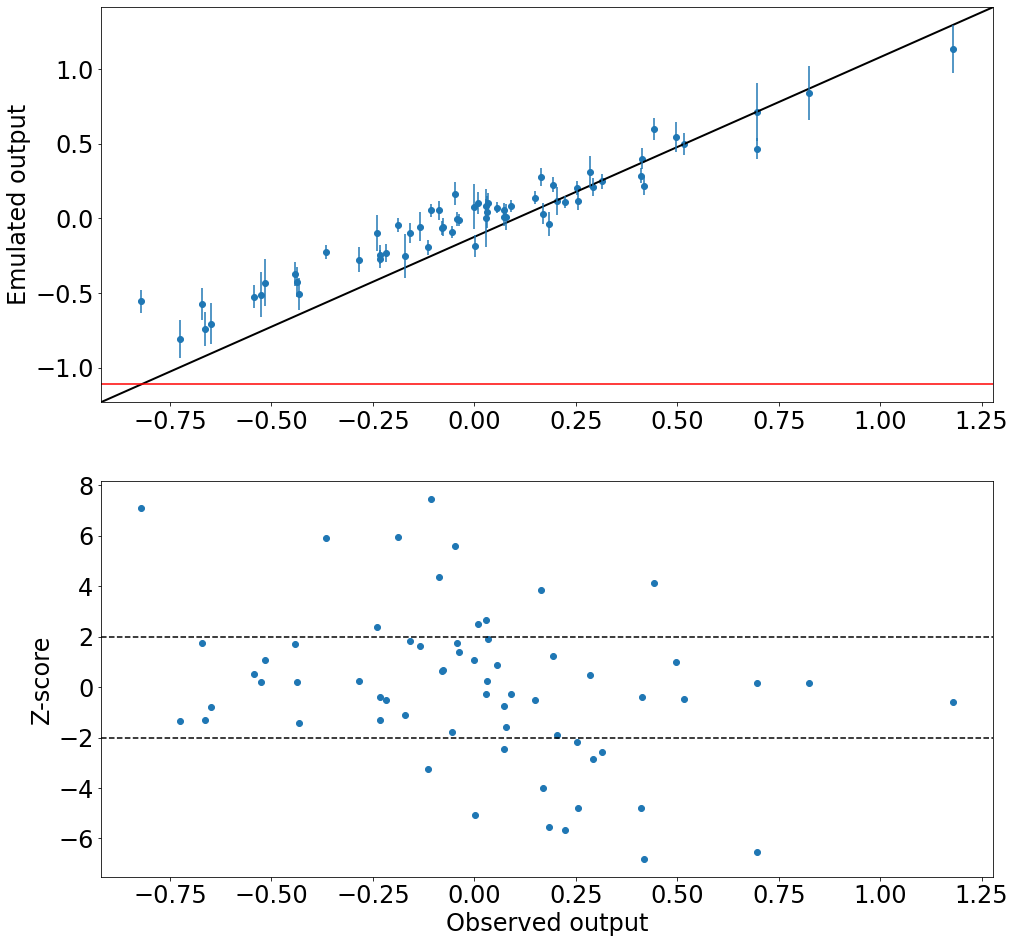

In [94]:
mu, var_f = m.predict_f(X.reshape(-1, X.shape[1]))
mu = mu.numpy().squeeze()
std_f = np.sqrt(var_f.numpy()).squeeze()
y = Y.squeeze()

fig, axv = plt.subplots(2,1, figsize=(16,16))

ax = axv[0]
ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='k', lw=2)
ax.scatter(Y, mu)
ax.errorbar(x=y, y=mu, yerr=2*std_f, fmt='none')
ax.axhline(y=refn, color='r', ls='-')
ax.set_ylabel('Emulated output')

ax = axv[1]
z = (mu-y) / std_f

ax.scatter(y, z)
ax.axhline(y=-2, color='k', ls='--')
ax.axhline(y=2, color='k', ls='--')
ax.set_xlabel('Observed output')
ax.set_ylabel('Z-score')

print(f'Percent of points within two standard deviations: {sum(abs(z)<2) / len(z):.1%}.');